In [1]:
import pickle

def preview_large_dict(filepath, num_items=10000):
    """ Load data from a pickle file and print a preview of a specified number of items. """
    with open(filepath, 'rb') as file:
        data = pickle.load(file)
        print("Data type:", type(data))
        print("Number of items in dictionary:", len(data))
        # Display a few items from the dictionary
        for i, (key, value) in enumerate(data.items()):
            if i < num_items:
                print(f"Key: {key} -> Value: {value}")
            else:
                break

# Path to the 'results.pkl' file
pkl_file_path = '/home/jaguir26/projects/results.pkl'

preview_large_dict(pkl_file_path)


Data type: <class 'dict'>
Number of items in dictionary: 1832084
Key: nwm.20180917/medium_range/nwm.t00z.medium_range.channel_rt.f069.conus.nc -> Value: 0.05999999865889549
Key: nwm.20180917/medium_range/nwm.t00z.medium_range.channel_rt.f036.conus.nc -> Value: 0.05999999865889549
Key: nwm.20180917/medium_range/nwm.t00z.medium_range.channel_rt.f033.conus.nc -> Value: 0.05999999865889549
Key: nwm.20180917/medium_range/nwm.t00z.medium_range.channel_rt.f162.conus.nc -> Value: 0.04999999888241291
Key: nwm.20180917/medium_range/nwm.t00z.medium_range.channel_rt.f129.conus.nc -> Value: 0.04999999888241291
Key: nwm.20180917/medium_range/nwm.t00z.medium_range.channel_rt.f066.conus.nc -> Value: 0.05999999865889549
Key: nwm.20180917/medium_range/nwm.t00z.medium_range.channel_rt.f009.conus.nc -> Value: 0.20999999530613422
Key: nwm.20180917/medium_range/nwm.t00z.medium_range.channel_rt.f096.conus.nc -> Value: 0.05999999865889549
Key: nwm.20180917/medium_range/nwm.t00z.medium_range.channel_rt.f159.co

In [2]:
import pickle
from datetime import datetime

def print_limited_forecast_keys_with_values(filepath, limit_per_scenario=5):
    """ Load data from a pickle file and selectively print a limited number of keys and their associated values based on forecast scenario. """
    with open(filepath, 'rb') as file:
        data = pickle.load(file)

    counts = {'scenario1': 0, 'scenario2': 0, 'scenario3': 0}

    # Iterate through each key in the dictionary
    for key in data.keys():
        # Extract and correctly parse the date part of the key
        date_part = key.split('/')[0]  # Assuming the key structure is 'nwm.YYYYMMDD/...'
        date_str = date_part.split('.')[1]  # This should now correctly parse as 'YYYYMMDD'

        forecast_date = datetime.strptime(date_str, '%Y%m%d')
        
        if forecast_date < datetime(2019, 6, 19) and counts['scenario1'] < limit_per_scenario:
            # Scenario 1: Before June 19, 2019
            if 'medium_range' in key and 't00z' in key:
                print(f"Scenario 1 Key: {key} -> Value: {data[key]}")
                counts['scenario1'] += 1
        
        elif datetime(2019, 6, 19) <= forecast_date < datetime(2021, 4, 21) and counts['scenario2'] < limit_per_scenario:
            # Scenario 2: June 19, 2019 to April 20, 2021
            if 'medium_range_mem' in key and 't12z' in key:
                print(f"Scenario 2 Key: {key} -> Value: {data[key]}")
                counts['scenario2'] += 1
        
        elif forecast_date >= datetime(2021, 4, 21) and counts['scenario3'] < limit_per_scenario:
            # Scenario 3: After April 21, 2021
            if 'medium_range_mem' in key and 't12z' in key:
                print(f"Scenario 3 Key: {key} -> Value: {data[key]}")
                counts['scenario3'] += 1

# Path to the 'results.pkl' file
pkl_file_path = '/home/jaguir26/projects/results.pkl'

print_limited_forecast_keys_with_values(pkl_file_path)


Scenario 1 Key: nwm.20180917/medium_range/nwm.t00z.medium_range.channel_rt.f069.conus.nc -> Value: 0.05999999865889549
Scenario 1 Key: nwm.20180917/medium_range/nwm.t00z.medium_range.channel_rt.f036.conus.nc -> Value: 0.05999999865889549
Scenario 1 Key: nwm.20180917/medium_range/nwm.t00z.medium_range.channel_rt.f033.conus.nc -> Value: 0.05999999865889549
Scenario 1 Key: nwm.20180917/medium_range/nwm.t00z.medium_range.channel_rt.f162.conus.nc -> Value: 0.04999999888241291
Scenario 1 Key: nwm.20180917/medium_range/nwm.t00z.medium_range.channel_rt.f129.conus.nc -> Value: 0.04999999888241291
Scenario 2 Key: nwm.20190619/medium_range_mem1/nwm.t12z.medium_range.channel_rt_1.f006.conus.nc -> Value: 1.409999968484044
Scenario 2 Key: nwm.20190619/medium_range_mem1/nwm.t12z.medium_range.channel_rt_1.f003.conus.nc -> Value: 1.5899999644607306
Scenario 2 Key: nwm.20190619/medium_range_mem1/nwm.t12z.medium_range.channel_rt_1.f009.conus.nc -> Value: 1.219999972730875
Scenario 2 Key: nwm.20190619/med

KeyboardInterrupt: 

In [3]:
import pickle
import pandas as pd
from datetime import datetime

def extract_forecast_data(filepath):
    """ Load data from a pickle file and organize it into a structured pandas DataFrame. """
    with open(filepath, 'rb') as file:
        data = pickle.load(file)

    # Prepare a list to collect all entries
    forecast_entries = []

    # Iterate through each key in the dictionary
    for key, value in data.items():
        parts = key.split('/')
        date_part = parts[0].split('.')[1]
        forecast_date = datetime.strptime(date_part, '%Y%m%d')
        ensemble_part = parts[1]

        if 'medium_range' in ensemble_part:
            if 'mem' in ensemble_part:
                ensemble_number = int(ensemble_part.split('mem')[1][0])
            else:
                ensemble_number = 1  # Assign to the first ensemble member if not specified
        else:
            ensemble_number = 1  # Default to 1 if no ensemble information is present

        lead_time = int(parts[2].split('f')[1].split('.')[0])

        # Append to the list as a tuple
        forecast_entries.append((forecast_date, ensemble_number, lead_time, value))

    # Create a DataFrame from the collected entries
    df = pd.DataFrame(forecast_entries, columns=['Date', 'Ensemble_Number', 'Lead_Time', 'Value'])

    return df

# Path to the 'results.pkl' file
pkl_file_path = '/home/jaguir26/projects/results.pkl'

# Extract data and print the DataFrame
forecast_df = extract_forecast_data(pkl_file_path)
print(forecast_df)


              Date  Ensemble_Number  Lead_Time      Value
0       2018-09-17                1         69   0.060000
1       2018-09-17                1         36   0.060000
2       2018-09-17                1         33   0.060000
3       2018-09-17                1        162   0.050000
4       2018-09-17                1        129   0.050000
...            ...              ...        ...        ...
1832079 2024-02-09                5        122  12.100000
1832080 2024-02-09                5        144  12.330000
1832081 2024-02-09                5        142  10.360000
1832082 2024-02-09                5        170  13.580000
1832083 2024-02-15                1         92  35.299999

[1832084 rows x 4 columns]


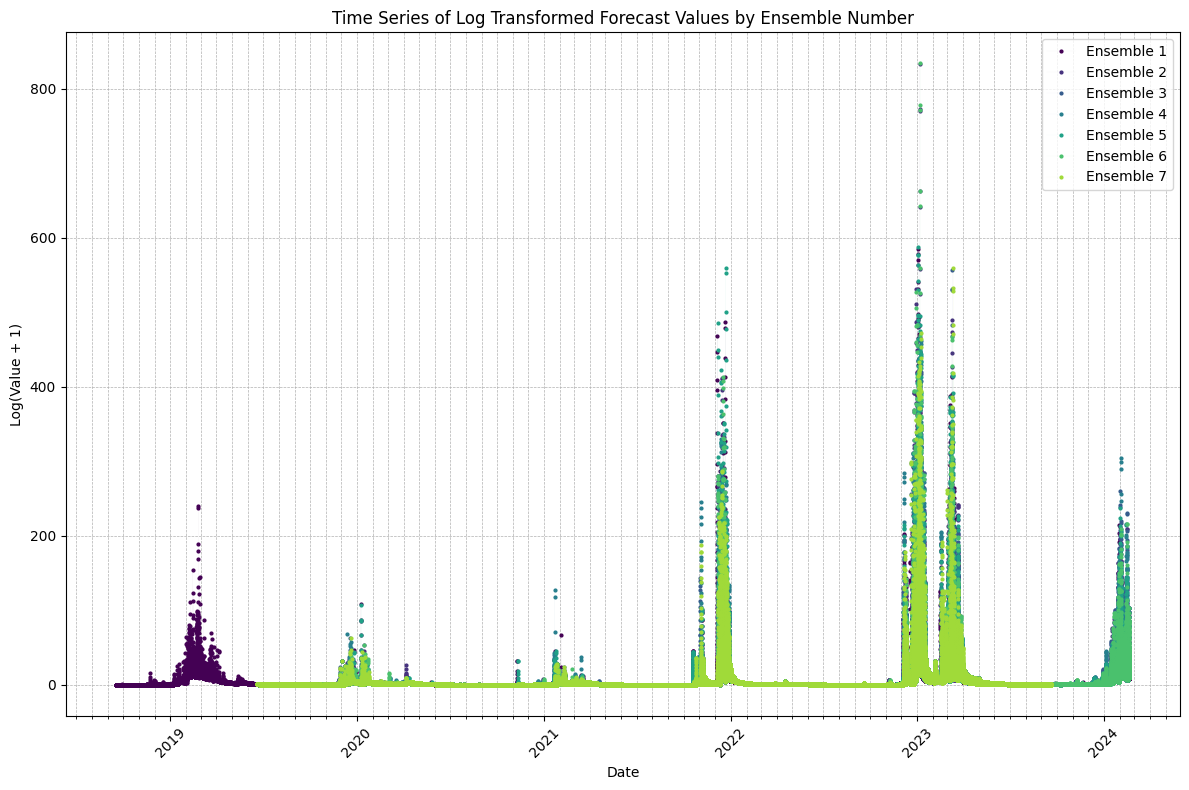

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.dates as mdates

def plot_all_ensemble_forecasts(df):
    # Set the figure size
    plt.figure(figsize=(12, 8))

    # Define a color map
    colormap = plt.cm.viridis  # You can change to any other colormap e.g., plt.cm.cividis

    # Get unique ensemble numbers
    ensemble_numbers = df['Ensemble_Number'].unique()
    num_ensembles = len(ensemble_numbers)
    
    # Create color gradient
    colors = [colormap(i / num_ensembles) for i in range(num_ensembles)]

    # Plot each ensemble
    for i, ensem_num in enumerate(sorted(ensemble_numbers)):
        # Filter data for each ensemble number and sort
        ensem_df = df[df['Ensemble_Number'] == ensem_num].sort_values(by=['Date', 'Lead_Time'])
        # ensem_df['Transformed Value'] = np.log(ensem_df['Value'] + 1)
        ensem_df['Transformed Value'] = ensem_df['Value'] 
        plt.plot(ensem_df['Date'], ensem_df['Transformed Value'], label=f'Ensemble {ensem_num}', color=colors[i], marker='.', linestyle='-', markersize=4, linewidth=0.01)

    # Set plot titles and labels
    plt.title('Time Series of Log Transformed Forecast Values by Ensemble Number')
    plt.xlabel('Date')
    plt.ylabel('Log(Value + 1)')

    # Enhance x-axis dates formatting
    plt.gca().xaxis.set_major_locator(mdates.YearLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.gca().xaxis.set_minor_locator(mdates.MonthLocator())
    plt.xticks(rotation=45)
    plt.legend(title='Ensemble Number', loc='upper left')

    # Add grid
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.legend()

    # Show plot
    plt.tight_layout()
    plt.show()

# Use the existing DataFrame 'forecast_df' and plot
plot_all_ensemble_forecasts(forecast_df)


In [5]:
import pandas as pd

# Assuming 'forecast_df' is your DataFrame
def save_to_feather(df, file_path):
    # Save the DataFrame to a Feather file
    df.to_feather(file_path)

# Specify the path where you want to save the file
feather_file_path = '/home/jaguir26/projects/forecast_data.feather'

# Call the function with your DataFrame
save_to_feather(forecast_df, feather_file_path)
